In this notebook, we will thoroughly explore the data from the selected Austrian stations. First, we will inspect all the columns in the dataset, understand them and decide how we will preprocess them. We will visualize some features to see the distribution of their values and to grasp some meaningful insights.

We will deal with missing values, choosing the best strategy for each case.

We will also create lag features, define the prediction horizon and prepare the train/val/test datasets for the enxt notebook.

## 0. Load the libraries

In [57]:
pip install seaborn


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pickle


# 1. Data inspection

In [59]:
# get the data we saved in the previous notebook
file_path = "../data/geosphere_data.csv"
data = pd.read_csv(file_path)

print(data.shape)

(54810, 133)


In [60]:
print(data.head())

                     time  station  bewd_i  bewd_i_flag  bewd_ii  \
0  2016-01-01T00:00+00:00        8     2.0           20      1.0   
1  2016-01-01T00:00+00:00       66     2.0           20      NaN   
2  2016-01-01T00:00+00:00       68     2.0           20      2.0   
3  2016-01-01T00:00+00:00       93     2.0           20      2.0   
4  2016-01-01T00:00+00:00       27     NaN           20      NaN   

   bewd_ii_flag  bewd_iii  bewd_iii_flag  bewm_i  bewm_i_flag  ...  \
0            20       2.0             20    10.0           20  ...   
1            20       NaN             20     9.0           20  ...   
2            20       NaN             20    10.0           20  ...   
3            20       2.0             20    10.0           20  ...   
4            20       NaN             20     NaN           20  ...   

   vvbft_i_flag  vvbft_ii  vvbft_ii_flag  vvbft_iii  vvbft_iii_flag  \
0            20       1.0             20        0.0              20   
1            20       1.0   

In [61]:
# Rename time column to date and convert to datetime format
data = data.rename(columns={'time': 'date'})
data['date'] = pd.to_datetime(data['date'])

# Extract date components
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

print(data.head())

                       date  station  bewd_i  bewd_i_flag  bewd_ii  \
0 2016-01-01 00:00:00+00:00        8     2.0           20      1.0   
1 2016-01-01 00:00:00+00:00       66     2.0           20      NaN   
2 2016-01-01 00:00:00+00:00       68     2.0           20      2.0   
3 2016-01-01 00:00:00+00:00       93     2.0           20      2.0   
4 2016-01-01 00:00:00+00:00       27     NaN           20      NaN   

   bewd_ii_flag  bewd_iii  bewd_iii_flag  bewm_i  bewm_i_flag  ...  vvbft_iii  \
0            20       2.0             20    10.0           20  ...        0.0   
1            20       NaN             20     9.0           20  ...        1.0   
2            20       NaN             20    10.0           20  ...        1.0   
3            20       2.0             20    10.0           20  ...        2.0   
4            20       NaN             20     NaN           20  ...        1.0   

   vvbft_iii_flag  vv_mittel  vv_mittel_flag   zeitx  zeitx_flag  substation  \
0           

In [62]:
data = data.rename(columns={'station': 'id'})

stations = pd.read_csv("../data/distributed_stations.csv")

# add information about stations to the main dataset
merged_data = pd.merge(data, stations[["id", "lat", "lon", "name"]], on="id", how="left")
print(merged_data)

                           date  id  bewd_i  bewd_i_flag  bewd_ii  \
0     2016-01-01 00:00:00+00:00   8     2.0           20      1.0   
1     2016-01-01 00:00:00+00:00  66     2.0           20      NaN   
2     2016-01-01 00:00:00+00:00  68     2.0           20      2.0   
3     2016-01-01 00:00:00+00:00  93     2.0           20      2.0   
4     2016-01-01 00:00:00+00:00  27     NaN           20      NaN   
...                         ...  ..     ...          ...      ...   
54805 2020-12-31 00:00:00+00:00  37     0.0           20      0.0   
54806 2020-12-31 00:00:00+00:00  20     NaN           20      NaN   
54807 2020-12-31 00:00:00+00:00  71     2.0           20      2.0   
54808 2020-12-31 00:00:00+00:00  43     NaN           20      NaN   
54809 2020-12-31 00:00:00+00:00  15     NaN           20      NaN   

       bewd_ii_flag  bewd_iii  bewd_iii_flag  bewm_i  bewm_i_flag  ...  \
0                20       2.0             20    10.0           20  ...   
1                20    

## 2.1 Flag columns

In [63]:
quality_flag_columns = [col for col in merged_data.columns if 'flag' in col]
for column in quality_flag_columns:
    unique_values = merged_data[column].unique()
    print(f"Unique values for column '{column}': {unique_values}")

Unique values for column 'bewd_i_flag': [20]
Unique values for column 'bewd_ii_flag': [20]
Unique values for column 'bewd_iii_flag': [20]
Unique values for column 'bewm_i_flag': [20]
Unique values for column 'bewm_ii_flag': [20]
Unique values for column 'bewm_iii_flag': [20]
Unique values for column 'bewm_mittel_flag': [20]
Unique values for column 'bft6_flag': [nan 20.]
Unique values for column 'bft8_flag': [nan 20.]
Unique values for column 'cglo_j_flag': [20]
Unique values for column 'dampf_i_flag': [20]
Unique values for column 'dampf_ii_flag': [20]
Unique values for column 'dampf_iii_flag': [20]
Unique values for column 'dampf_mittel_flag': [20]
Unique values for column 'dd32_i_flag': [20]
Unique values for column 'dd32_ii_flag': [20]
Unique values for column 'dd32_iii_flag': [20]
Unique values for column 'erdb_i_flag': [20]
Unique values for column 'erdb_ii_flag': [20]
Unique values for column 'erdb_iii_flag': [20]
Unique values for column 'ffx_flag': [20]
Unique values for colum

In the *parameters metadata* flag columns are described as quality flags for the corresponding numerical column and they contain the code.

By printing unique values for all these columns, we can notice that we have :
1. Uniform Values ([20]):

Most flags have the value 20 across all rows. These columns are not providing any variability or useful information.
Examples: bewd_i_flag, bewd_ii_flag, bewm_i_flag, etc.

2. Columns with NaN Values:

Some flags are entirely NaN, which means they also contain no usable information.
Examples: bft6_flag, bft8_flag, gew_flag, etc.

Hence, we will simply drop all the flag columns:


In [64]:
data_cleaned = merged_data.drop(columns=quality_flag_columns)
print("New dataset size after removing flag columns:", data_cleaned.shape)

New dataset size after removing flag columns: (54810, 74)


## 2.2 Aggregated features

In our dataset we have aggregated features, for example, bewm_mittel. It is calculated as (bewm_i + bewm_ii + bewm_iii)/3 * 10. Including both the individual features and the aggregation creates redundant information, which can inflate the importance of cloud cover in the model.


So, we need to choose if we will leave individual features or an aggregated feature in the dataset.

Our target features (tlmax, tlmin, tl_mittel) are strongly influenced by time-specific weather conditions:
* tlmax (maximum temperature) is directly affected by
conditions during the daytime.


* tlmin (minimum temperature) is influenced by overnight conditions.


Aggregating the features into bewm_mittel assumes that all three time periods contribute equally to the temperature patterns. However cloud cover at 06 UTC (morning) may have a different impact on temperature than at 18 UTC (evening).


Hence, we will be using individual features.

In [65]:
data_cleaned = data_cleaned.drop(['bewm_mittel','dampf_mittel', 'p_mittel', 'rf_mittel', 'vv_mittel', 'rr', 'rra_manu'], axis=1)
print("New dataset size after removing aggregated features:", data_cleaned.shape)

New dataset size after removing aggregated features: (54810, 67)


# 3. Visualizations

## 3.1 Indicator columns

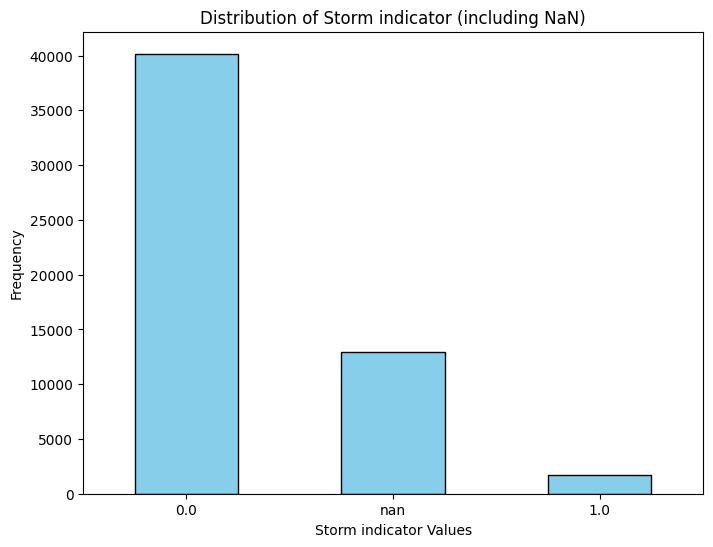

In [66]:
# Calculate value counts, including NaN
value_counts = data_cleaned['bft6'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Storm indicator (including NaN)')
plt.xlabel('Storm indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

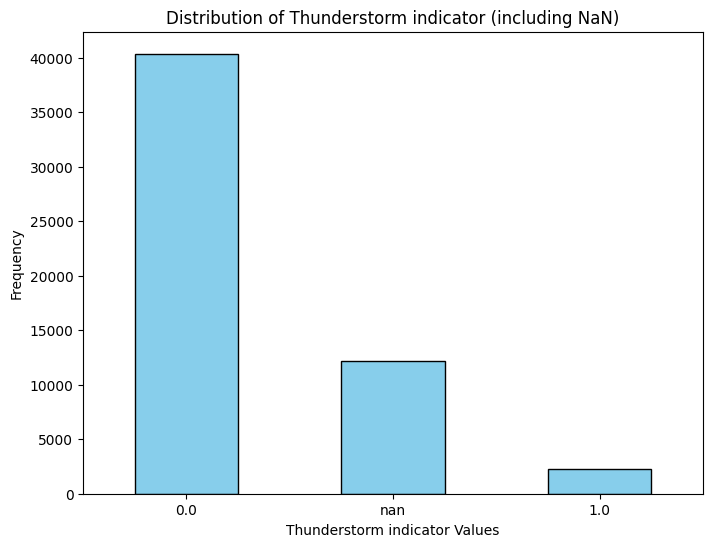

In [67]:
# Calculate value counts, including NaN
value_counts = data_cleaned['gew'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Thunderstorm indicator (including NaN)')
plt.xlabel('Thunderstorm indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

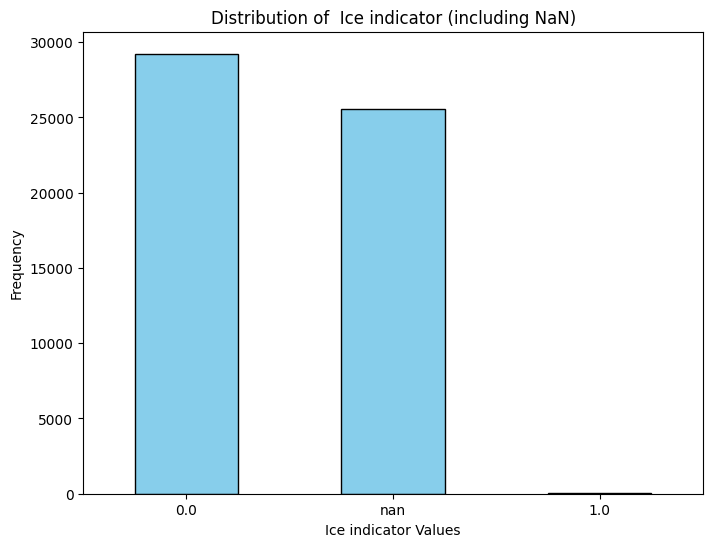

In [68]:
# Calculate value counts, including NaN
value_counts = data_cleaned['glatt'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of  Ice indicator (including NaN)')
plt.xlabel('Ice indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

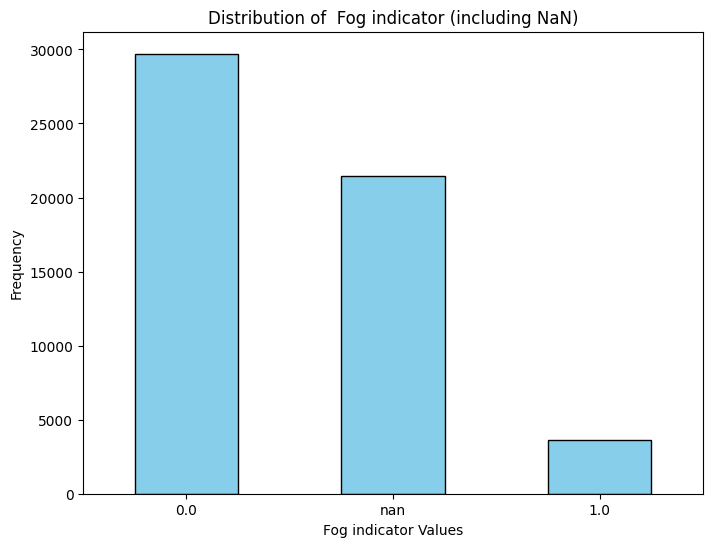

In [69]:
# Calculate value counts, including NaN
value_counts = data_cleaned['nebel'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of  Fog indicator (including NaN)')
plt.xlabel('Fog indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

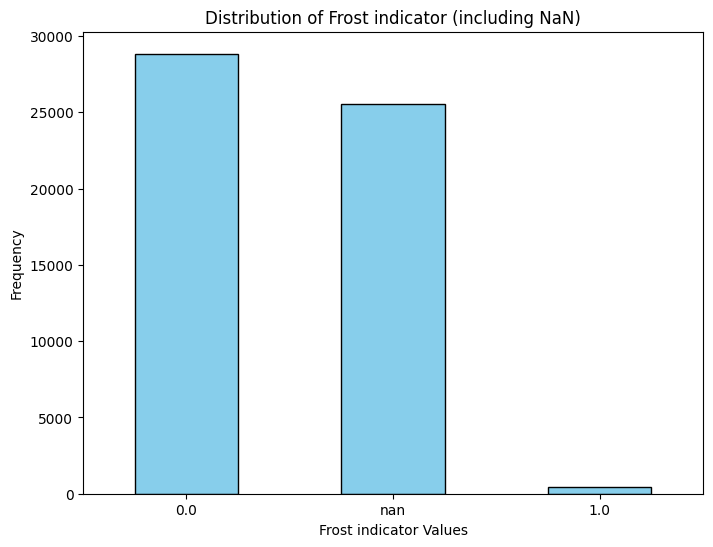

In [70]:
# Calculate value counts, including NaN
value_counts = data_cleaned['raureif'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Frost indicator (including NaN)')
plt.xlabel('Frost indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

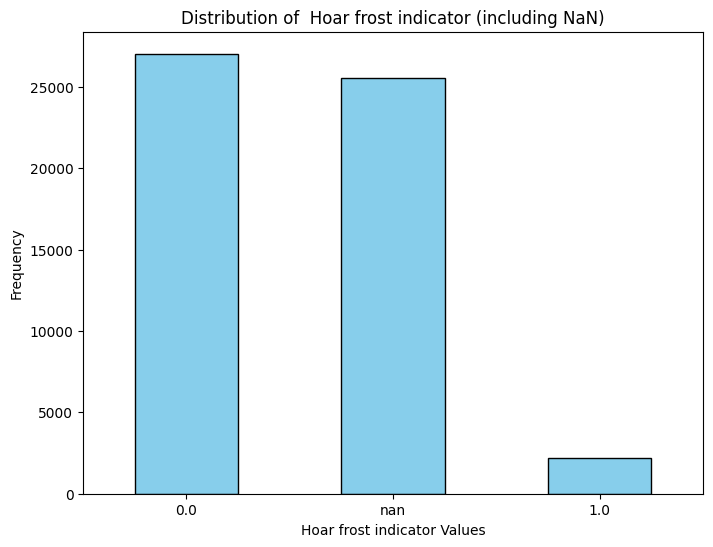

In [71]:
# Calculate value counts, including NaN
value_counts = data_cleaned['reif'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of  Hoar frost indicator (including NaN)')
plt.xlabel('Hoar frost indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

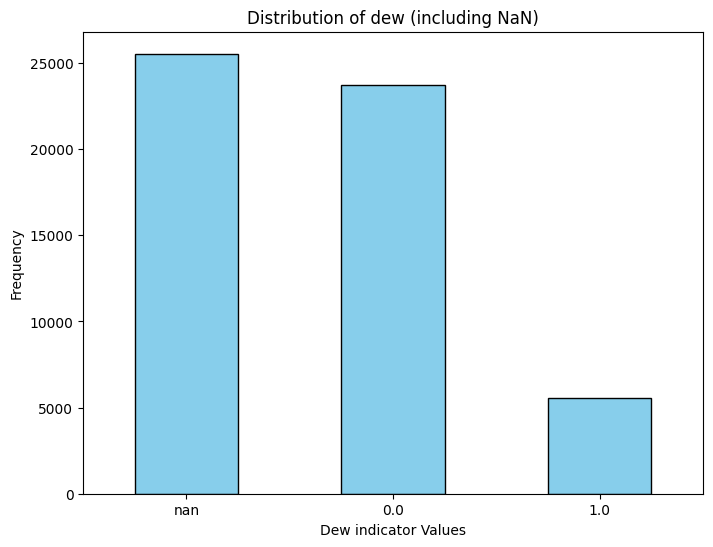

In [72]:
# Calculate value counts, including NaN
value_counts = data_cleaned['tau'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of dew (including NaN)')
plt.xlabel('Dew indicator Values')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

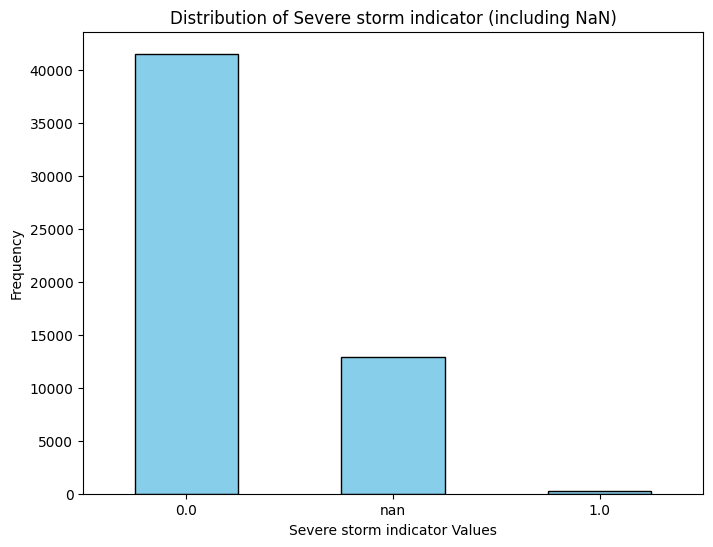

In [73]:
value_counts = data_cleaned['bft8'].value_counts(dropna=False)

# Create the bar plot
plt.figure(figsize=(8, 6))
value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Severe storm indicator (including NaN)')
plt.xlabel('Severe storm indicator Values')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

The visualizations above show the distribution of several meteorological indicators with three primary values: 0 (absence), 1 (presence), and NaN (missing values). We can notice a heavy class imbalance - in most cases, 1 (indicating a severe condition like a storm) is much less frequent than 0. Also for some cases the proportion of missing values is very high (>50%), so we will consider dropping these columsn as they may not provide useful information (in section Missing Values).

## 3.2 Nominal Features

C:\Users\Мария\AppData\Local\Temp\ipykernel_24492\3675323513.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([rra_manu_mapping[int(float(label.get_text()))] for label in ax.get_xticklabels()])


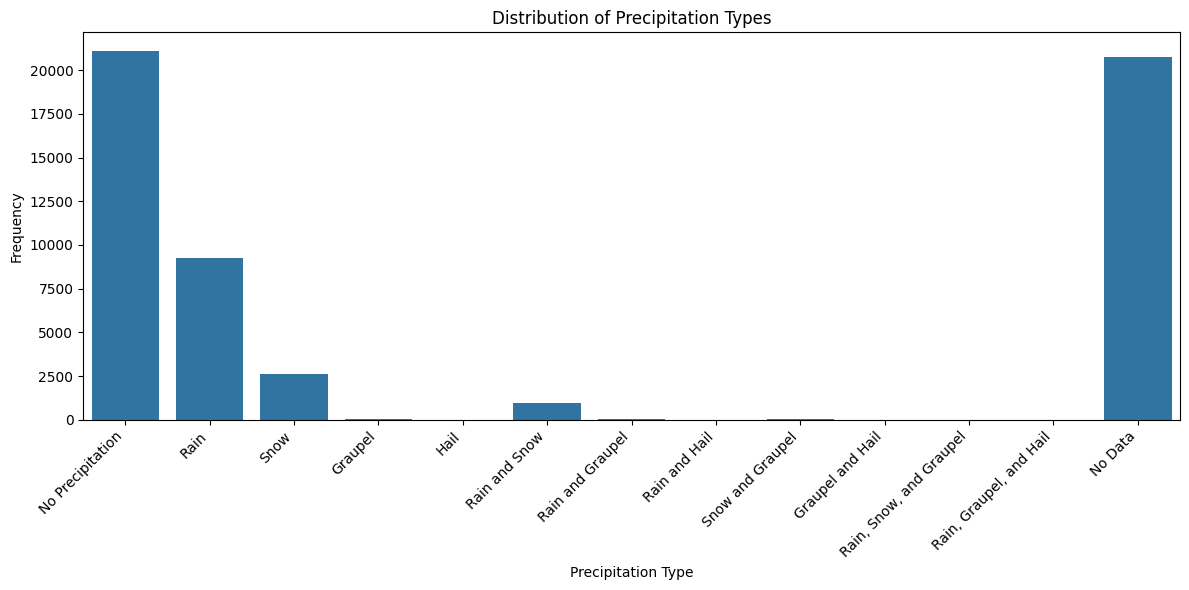

In [74]:
# Mapping for rra_manu codes to descriptions, including NaN
rra_manu_mapping = {
    0: 'No Precipitation',
    1: 'Rain',
    2: 'Snow',
    3: 'Graupel',
    4: 'Hail',
    5: 'Rain and Snow',
    6: 'Rain and Graupel',
    7: 'Rain and Hail',
    8: 'Snow and Graupel',
    9: 'Graupel and Hail',
    10: 'Rain, Snow, and Graupel',
    11: 'Rain, Graupel, and Hail',
    12: 'Snow and Hail',
    13: 'Rain, Snow, and Hail',
    14: 'Snow, Graupel, and Hail',
    15: 'Rain, Snow, Graupel, and Hail',
    99: 'No Data'
}

# Replace NaN values in 'rra_manu_i' with a string '99' temporarily for plotting
data_cleaned['rra_manu_i_plot'] = data_cleaned['rra_manu_i'].fillna(99)

# Plotting the distribution of precipitation types
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='rra_manu_i_plot', data=data_cleaned)
ax.set_xticklabels([rra_manu_mapping[int(float(label.get_text()))] for label in ax.get_xticklabels()])
plt.xlabel("Precipitation Type")
plt.ylabel("Frequency")
plt.title("Distribution of Precipitation Types")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Remove the temporary column after plotting
data_cleaned.drop(columns=['rra_manu_i_plot'], inplace=True)


This feature is a bit complicated and we will simplify it by just extracting rain information to a new column.

In [75]:
# Define the set of values indicating rain in the 'rra_manu_i' column
rain_values = [1, 5, 6, 7, 10, 11, 13, 15]

# Create the 'regen_i' column based on the condition
data_cleaned['regen_i'] = data_cleaned['rra_manu_i'].apply(lambda x: 1 if x in rain_values else 0)
data_cleaned['regen_ii'] = data_cleaned['rra_manu_iii'].apply(lambda x: 1 if x in rain_values else 0)

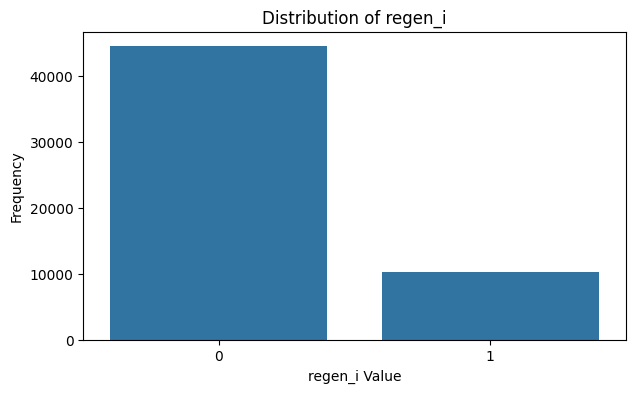

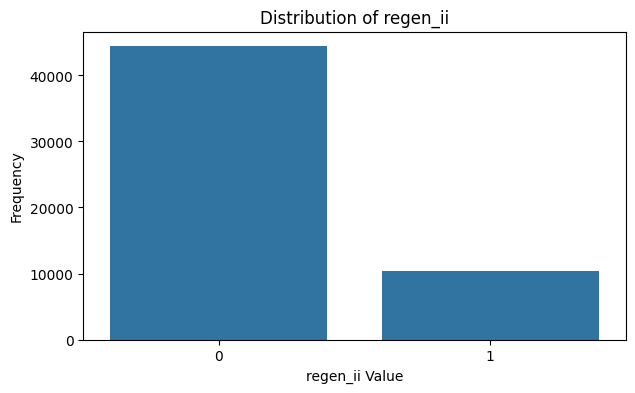

In [76]:
plt.figure(figsize=(7, 4))
sns.countplot(x='regen_i', data=data_cleaned)
plt.title('Distribution of regen_i')
plt.xlabel('regen_i Value')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x='regen_ii', data=data_cleaned)
plt.title('Distribution of regen_ii')
plt.xlabel('regen_ii Value')
plt.ylabel('Frequency')
plt.show()

C:\Users\Мария\AppData\Local\Temp\ipykernel_24492\2307219721.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([soil_condition_mapping[int(float(label.get_text()))] for label in ax.get_xticklabels()])


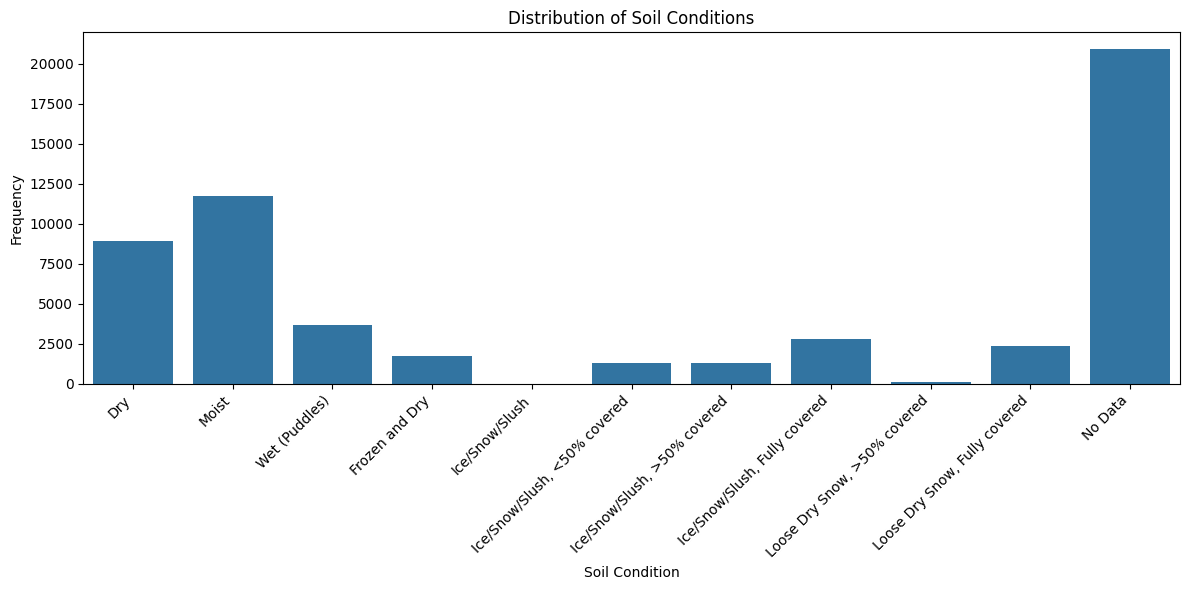

In [77]:
# Mapping for soil condition codes to descriptions
soil_condition_mapping = {
    0: 'Dry',
    1: 'Moist',
    2: 'Wet (Puddles)',
    3: 'Frozen and Dry',
    4: 'Ice/Snow/Slush',
    5: 'Ice/Snow/Slush, <50% covered',
    6: 'Ice/Snow/Slush, >50% covered',
    7: 'Ice/Snow/Slush, Fully covered',
    8: 'Loose Dry Snow, >50% covered',
    9: 'Loose Dry Snow, Fully covered',
    99: 'No Data'
}

# Replace NaN values in 'erdb_i' with a string 'NaN' temporarily for plotting
data_cleaned['erdb_i_plot'] = data_cleaned['erdb_i'].fillna(99)

# Plotting the distribution of soil conditions
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='erdb_i_plot', data=data_cleaned)
ax.set_xticklabels([soil_condition_mapping[int(float(label.get_text()))] for label in ax.get_xticklabels()])
plt.xlabel("Soil Condition")
plt.ylabel("Frequency")
plt.title("Distribution of Soil Conditions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Remove the temporary column after plotting
data_cleaned.drop(columns=['erdb_i_plot'], inplace=True)


C:\Users\Мария\AppData\Local\Temp\ipykernel_24492\2880854677.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([snow_type_mapping[int(float(label.get_text()))] for label in ax.get_xticklabels()])


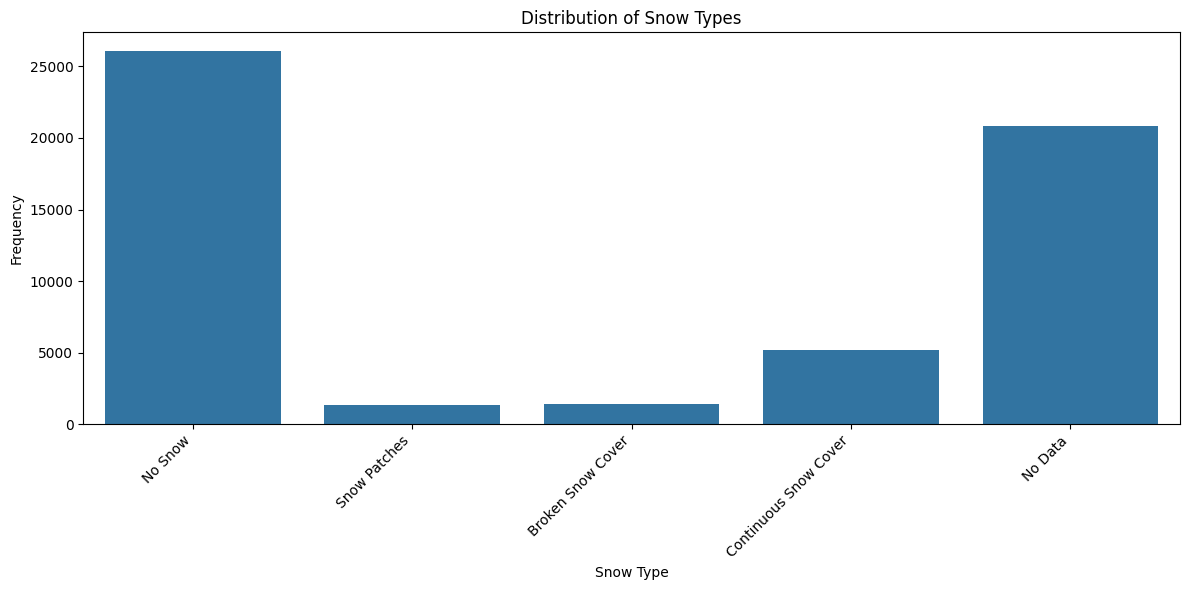

In [78]:
# Mapping for snow type codes to descriptions
snow_type_mapping = {
    0: 'No Snow',
    1: 'Snow Patches',
    2: 'Broken Snow Cover',
    3: 'Continuous Snow Cover',
    9: 'No Data'
}

# Replace NaN values in 'sha_manu' with a string 'NaN' temporarily for plotting
data_cleaned['sha_manu_plot'] = data_cleaned['sha_manu'].fillna(9)

# Plotting the distribution of snow types
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='sha_manu_plot', data=data_cleaned)
ax.set_xticklabels([snow_type_mapping[int(float(label.get_text()))] for label in ax.get_xticklabels()])

plt.xlabel("Snow Type")
plt.ylabel("Frequency")
plt.title("Distribution of Snow Types")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Remove the temporary column after plotting
data_cleaned.drop(columns=['sha_manu_plot'], inplace=True)


We will also simplify this feature:

In [79]:
data_cleaned['is_snowy'] = data_cleaned['sha_manu'].apply(lambda x: 1 if x in [1, 2, 3] else 0 if x == 0 else np.nan)

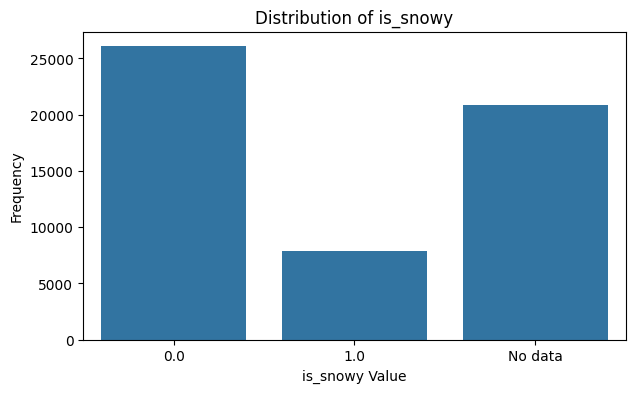

In [80]:
# Replace NaN values in 'is_snowy' with a temporary label for plotting
data_cleaned['is_snowy_plot'] = data_cleaned['is_snowy'].fillna('No data')

# Create the plot
plt.figure(figsize=(7, 4))
sns.countplot(x='is_snowy_plot', data=data_cleaned)
plt.title('Distribution of is_snowy')
plt.xlabel('is_snowy Value')
plt.ylabel('Frequency')
plt.show()

# Remove the temporary column after plotting
data_cleaned.drop(columns=['is_snowy_plot'], inplace=True)

## 3.3 Numerical Features

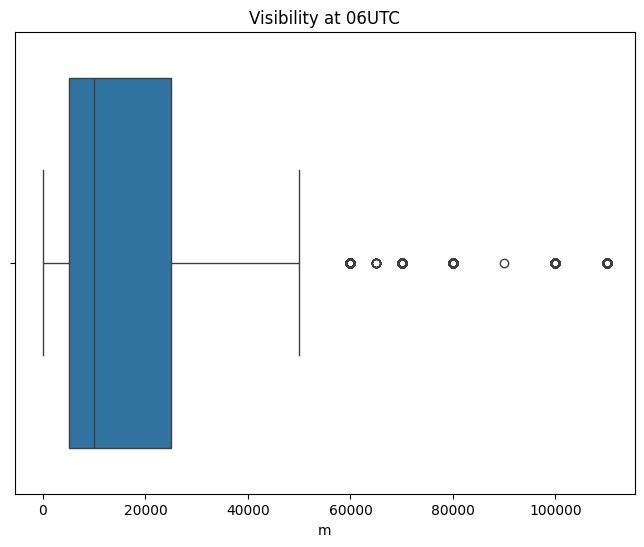

In [81]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='sicht_i', data=data_cleaned)
plt.title('Visibility at 06UTC')
plt.xlabel('m')
plt.show()

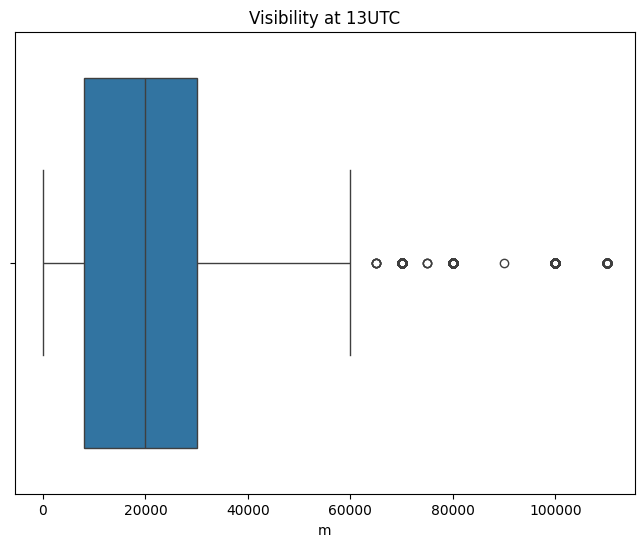

In [82]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='sicht_ii', data=data_cleaned)
plt.title('Visibility at 13UTC')
plt.xlabel('m')
plt.show()

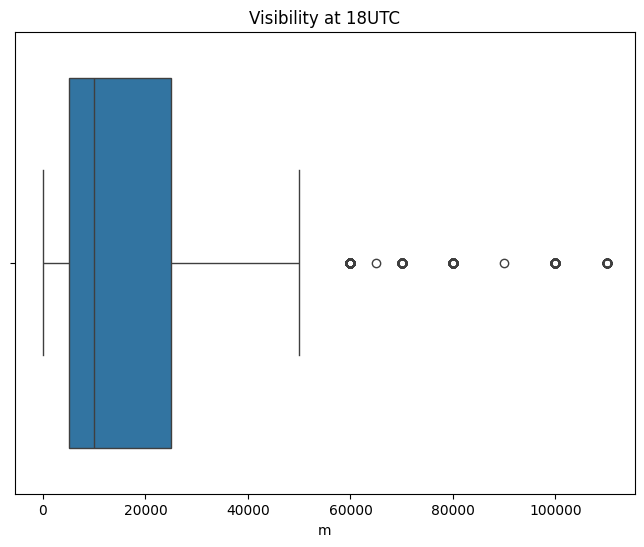

In [83]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='sicht_iii', data=data_cleaned)
plt.title('Visibility at 18UTC')
plt.xlabel('m')
plt.show()

The distribution is skewed, with outliers above 60,000 meters.

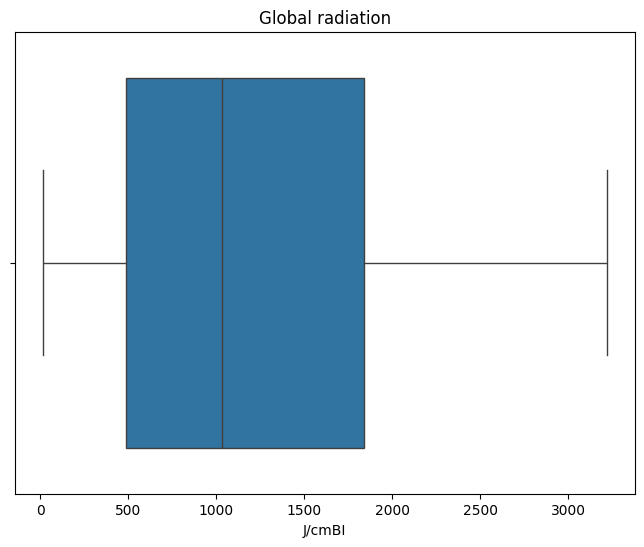

In [84]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='cglo_j', data=data_cleaned)
plt.title('Global radiation')
plt.xlabel('J/cmВІ')
plt.show()

The distribution appears symmetrical, with no extreme outliers. Values are concentrated between 500 and 2,500 J/cm².

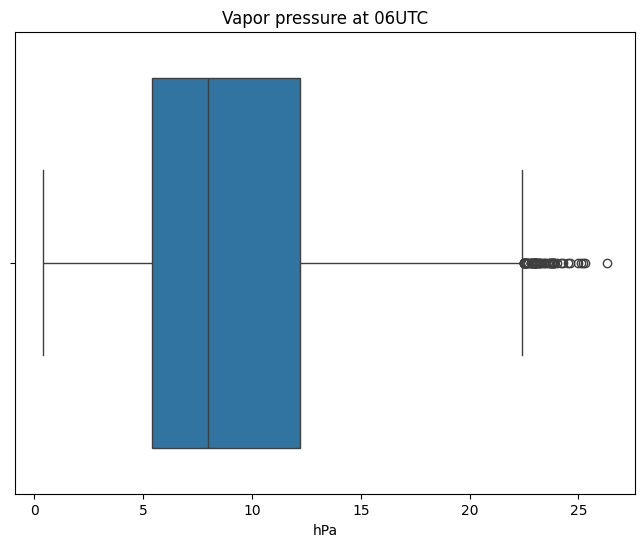

In [85]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='dampf_i', data=data_cleaned)
plt.title('Vapor pressure at 06UTC')
plt.xlabel('hPa')
plt.show()

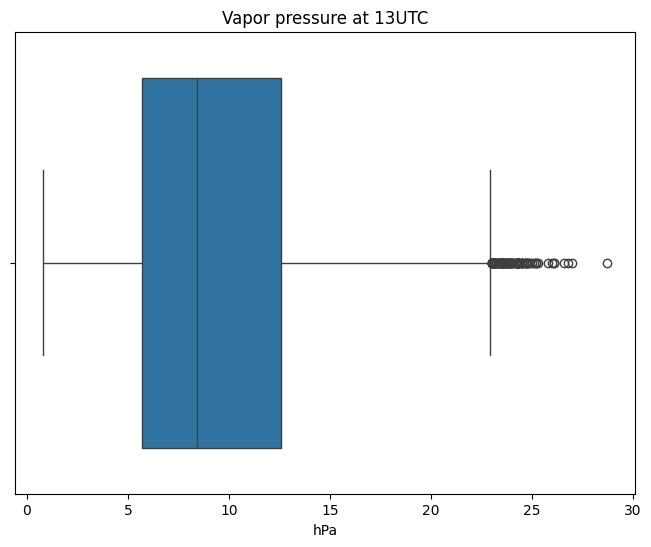

In [86]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='dampf_ii', data=data_cleaned)
plt.title('Vapor pressure at 13UTC')
plt.xlabel('hPa')
plt.show()

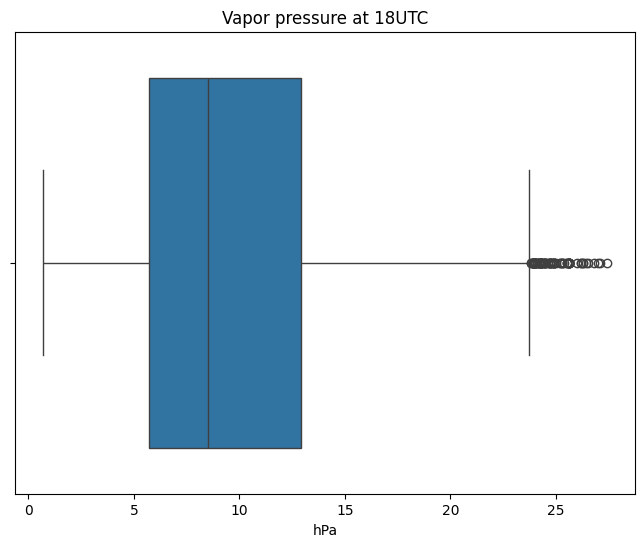

In [87]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='dampf_iii', data=data_cleaned)
plt.title('Vapor pressure at 18UTC')
plt.xlabel('hPa')
plt.show()

The distribution has several outliers, especially above 25 hPa.

# Feature Summary

## Indicators

| **Feature**   | **Description**                                 | **Unique Values** | **Action**                             |
|---------------|-------------------------------------------------|-------------------|----------------------------------------|
| bft6          | Storm Indicator                                | 0, 1, NaN         | Imput missing values        |
| bft8          | Severe Storm Indicator                         | 0, NaN            | Drop        |
| gew           | Thunderstorm Indicator                         | 0, 1, NaN         | Imput missing values        |
| glatt         | Black Ice Indicator                            | 0, 1, NaN         | Imput missing values        |
| nebel         | Fog Indicator                                  | 0, 1, NaN         | Imput missing values        |
| raureif       | Hoarfrost Indicator                            | 0, 1, NaN         | Imput missing values        |
| reif          | Frost Indicator                                | 0, 1, NaN         | Imput missing values        |
| tau           | Dew Indicator                                  | 0, 1, NaN         | Imput missing values        |

---

## Aggregated

| **Feature**   | **Description**                                 | **Unique Values** | **Action**                             |
|---------------|-------------------------------------------------|-------------------|----------------------------------------|
| bewd_mittel   | Mean Cloud Density                              | [0-100], NaN      | Drop (aggregation)      |
| bewm_mittel   | Mean Cloud Cover                                | [0-100], NaN      | Drop (aggregation)      |
| dampf_mittel  | Mean Vapor Pressure                             | Continuous, NaN   | Drop (aggregation)            |
| p_mittel      | Mean Air Pressure                               | Continuous, NaN   | Drop (aggregation)            |
| rf_mittel     | Mean Relative Humidity                          | [0-100], NaN      | Drop (aggregation)            |

---

## Cyclic

| **Feature**   | **Description**                                 | **Unique Values** | **Action**                             |
|---------------|-------------------------------------------------|-------------------|----------------------------------------|
| dd32_i        | Wind Direction at Observation Time I (Cyclic)   | [0-32], NaN       | Encode cyclically    |
| dd32_ii       | Wind Direction at Observation Time II (Cyclic)  | [0-32], NaN       | Encode cyclically    |
| dd32_iii      | Wind Direction at Observation Time III (Cyclic) | [0-32], NaN       | Encode cyclically    |

---

## Nominal

| **Feature**   | **Description**                                 | **Unique Values**          | **Action**                             |
|---------------|-------------------------------------------------|----------------------------|----------------------------------------|
| rra_manu_i    | Precipitation Type at Observation Time I        | Categories' codes                | Transform to regen_i    |
| erdb_i, erdb_ii, erdb_iii        | Soil Condition at Observation Time I, II, III            | Categories' codes                | Imput missing values    |
| sha_manu      | Snow Type, calculated from Soil Condition       | Categories' codes                | Transform to is_snowy    |
| rra_manu_iii  | Precipitation Type at Observation Time III      | Categories' codes                | Transform to regen_ii    |

---

## Numerical

| **Feature**   | **Description**                                 | **Unique Values**          | **Action**                             |
|---------------|-------------------------------------------------|----------------------------|----------------------------------------|
| sicht_i, sicht_ii, sicht_iii       | Visibility at Observation Time I, II, III                | Continuous, NaN            | Imput missing values            |
| ffx           | Maximum Wind Speed                      | Continuous, NaN            | Imput missing values            |
| dampf_i, dampf_ii, dampf_iii       | Vapor Pressure at Observation Time I, II, III            | Continuous, NaN            | Imput missing values            |
| p_i, p_ii, p_iii           | Air Pressure at Observation Time I, II, III              | Continuous, NaN            | Imput missing values            |
| rf_i, rf_ii, rf_iii          | Relative Humidity at Observation Time I, II, III         | [0-100], NaN               | Imput missing values            |
| cglo_j | Global radiation | Continuous, NaN | Imput missing values            |
| rr_i, rr_ii | Precipitation 12h total for observation date I, II | Continuous, NaN | Imput missing values            |
| sh_manu | Total snow depth, manual measurement | Continuous, NaN | Imput missing values            |
| shneu_manu | New snow depth, manual measurement | Continuous, NaN | Imput missing values            |
| so_h | Duration of sunshine | Continuous, NaN | Imput missing values            |

---

## Ordinal

| **Feature**   | **Description**                                 | **Unique Values**          | **Action**                             |
|---------------|-------------------------------------------------|----------------------------|----------------------------------------|
| bewd_i, bewd_ii, bewd_iii        | Cloud Density at Observation Time I, II, III             | [0, 1, 2], NaN             | Imput missing values      |
| bewm_i, bewm_ii, bewm_iii        | Cloud Cover at Observation Time I, II, III               | [0-10], NaN                | Imput missing values      |
| vvbft_i, vvbft_ii, vvbft_iii | Wind strength at observation date I, II, III | [0-12] | Imput missing values      |


# 4. Missing values

First let's drop the columns which we don't need anymore after feature engineering in the previous section:

In [88]:
data_cleaned = data_cleaned.drop(['rra_manu_i', 'rra_manu_iii', 'sha_manu'], axis=1)

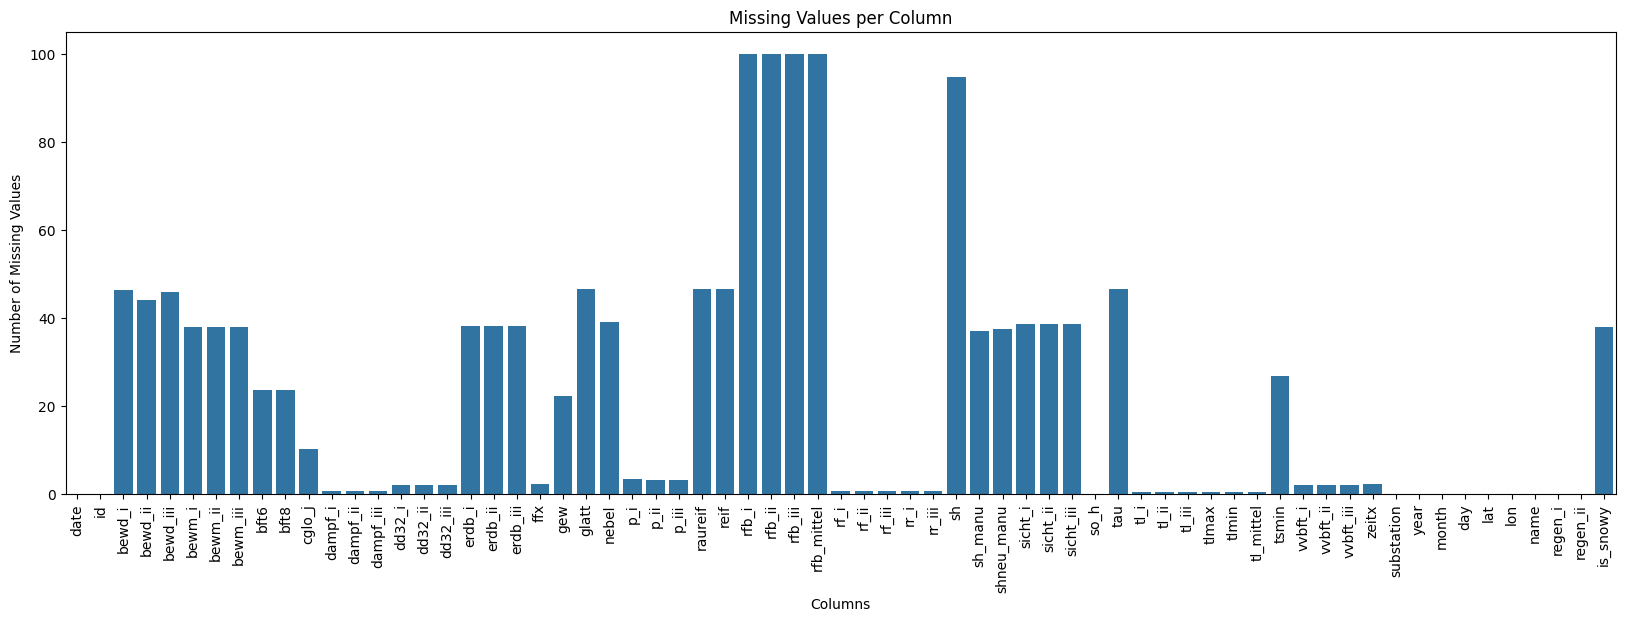

In [89]:
# Check missing values
missing_values = data_cleaned.isnull().sum()
missing_values_per = missing_values / len(data_cleaned) * 100

# Create a bar plot for missing values
plt.figure(figsize=(20, 6))
sns.barplot(x=missing_values.index, y=missing_values_per.values)
plt.xticks(rotation=90)
plt.title("Missing Values per Column")
plt.ylabel("Number of Missing Values")
plt.xlabel("Columns")
plt.show()

Columns with missing values differ in the proportion of missing values. We will divide them into 3 categories:

* Columns with >50% missing values - we will simply remove them, because they do not carry any information
* Columns with > 5% missing values - we will have to investigate them
* Columns with < 5% and > 0% missing values - we will imput missing values

## 4.1 High missing values

In [90]:
# Identify columns with >50% missing values
columns_to_drop = missing_values_per[missing_values_per > 50].index
print("Dropped the columns: ", columns_to_drop.values)
missing_values_per = missing_values_per[missing_values_per <= 50]

# Drop the identified columns from the DataFrame
data_cleaned = data_cleaned.drop(columns=columns_to_drop)

# Now filtered_data contains the DataFrame with the columns dropped.
print("Dataset size after removing columns with 100% missing values:", data_cleaned.shape)

Dropped the columns:  ['rfb_i' 'rfb_ii' 'rfb_iii' 'rfb_mittel' 'sh']
Dataset size after removing columns with 100% missing values: (54810, 62)


## 4.2 Moderate missing values

In [91]:
columns_with_moderate_missing = missing_values_per[missing_values_per > 5]

In [92]:
# Filter `parameter_data` to include only parameters with missing values
# Extract the parameter names from `columns_with_moderate_missing`
columns_with_moderate_missing_names = columns_with_moderate_missing.index

parameters_data = pd.read_csv('../data/parameters.csv')
# Filter `parameter_data` based on these parameter names
parameters_with_moderate_missing = parameters_data[parameters_data['Parameterkürzel'].isin(columns_with_moderate_missing_names)]

# Merge the missing percentages with the explanations
# Create a DataFrame for the missing percentages
missing_df = columns_with_moderate_missing.reset_index()
missing_df.columns = ['Parameterkürzel', 'Missing Percentage']

# Merge the two DataFrames on the `Parameterkürzel` column
merged_data = pd.merge(missing_df, parameters_with_moderate_missing, on='Parameterkürzel', how='inner')

print("Parameters with Missing Values > 5%:")
print(merged_data[['Parameterkürzel','Beschreibung', 'Missing Percentage']])


Parameters with Missing Values > 5%:
   Parameterkürzel                                       Beschreibung  \
0           bewd_i  Bewölkungsdichte zum Beobachtungstermin I (06 ...   
1          bewd_ii  Bewölkungsdichte zum Beobachtungstermin II (13...   
2         bewd_iii  Bewölkungsdichte zum Beobachtungstermin III (1...   
3           bewm_i  Bewölkungsmenge zum Beobachtungstermin I (06 U...   
4          bewm_ii  Bewölkungsmenge zum Beobachtungstermin II (13 ...   
5         bewm_iii  Bewölkungsmenge zum Beobachtungstermin III (18...   
6             bft6  Windstärke >= 6 Beaufort oder >= 60 km/h - Cod...   
7             bft8  Windstärke >= 8 Beaufort oder >= 80 km/h - Cod...   
8           cglo_j  Globalstrahlung, kalibrierte 24-Stundensumme a...   
9           erdb_i  Erdbodenzustand zum Beobachtungstermin I (06 U...   
10         erdb_ii  Erdbodenzustand zum Beobachtungstermin II (13 ...   
11        erdb_iii  Erdbodenzustand zum Beobachtungstermin III (18...   
12            

These parameters have 5%–50% missing values, which is significant. Everything connected to cloud cover is 30-40% missing. Storm, ground conditions, rare weather events and snow related parameters are also missing. We will now check, how the missing values are distributed for different stations.

C:\Users\Мария\AppData\Local\Temp\ipykernel_24492\1962949356.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_station = relevant_parameters.groupby(stations_column).apply(lambda x: x.isnull().mean() * 100)


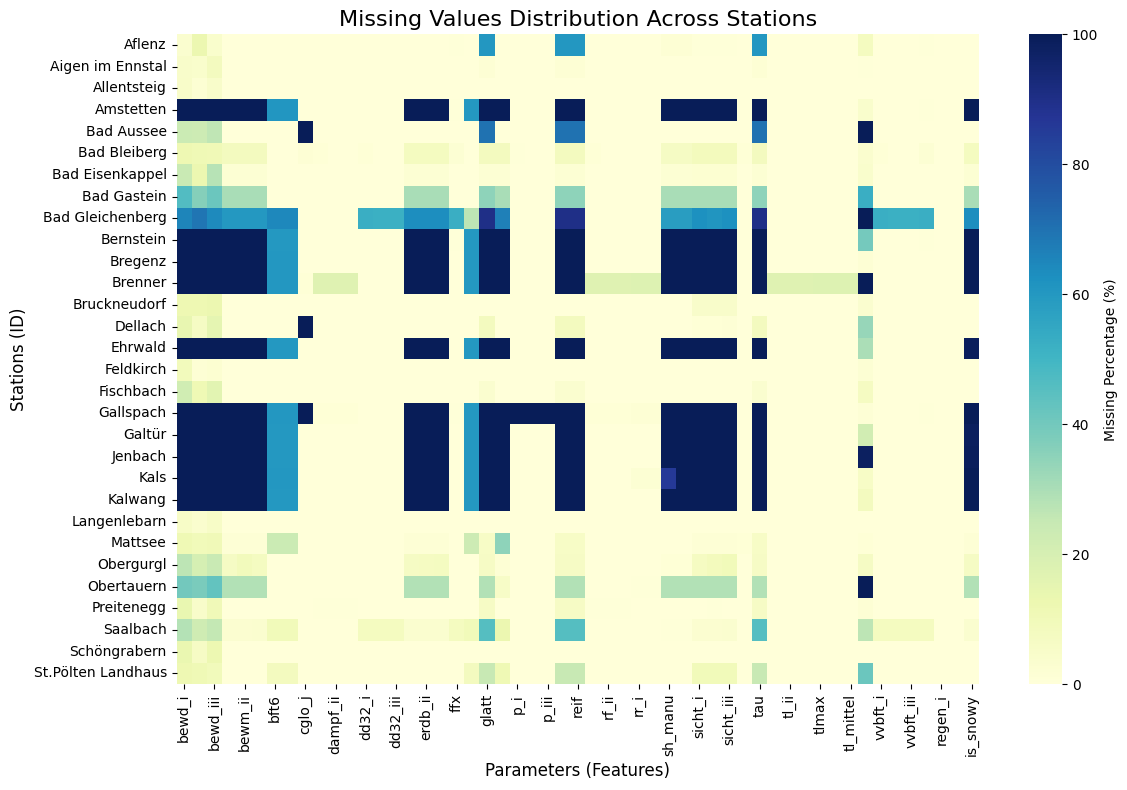

In [93]:
stations_column = 'name'

# Filter dataset to retain only relevant parameters, dropping unnecessary columns
relevant_parameters = data_cleaned.drop(columns=['date', 'year', 'month', 'day', 'lat', 'lon', 'id', 'substation'])

# Calculate the percentage of missing values for each station
missing_by_station = relevant_parameters.groupby(stations_column).apply(lambda x: x.isnull().mean() * 100)

# Prepare filtered dataset for plotting
# Drop the station column if it's included in the resulting DataFrame
if stations_column in missing_by_station.columns:
    filtered_missing_by_station = missing_by_station.drop(columns=[stations_column])
else:
    filtered_missing_by_station = missing_by_station

# Plot the heatmap of missing values distribution across stations
plt.figure(figsize=(12, 8))
sns.heatmap(
    filtered_missing_by_station,
    cmap="YlGnBu",
    annot=False,
    cbar_kws={'label': 'Missing Percentage (%)'}
)

plt.title("Missing Values Distribution Across Stations", fontsize=16)
plt.xlabel("Parameters (Features)", fontsize=12)
plt.ylabel("Stations (ID)", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()


Let's check the missing percentage for each station:

In [94]:
# Group by station name and calculate the missing percentage
missing_by_name = data_cleaned.groupby('name').apply(lambda x: x.isnull().mean() * 100)

# Sort the results by the overall missing percentage for better understanding
missing_by_name['Overall Missing Percentage'] = missing_by_name.mean(axis=1)
missing_by_name_sorted = missing_by_name.sort_values('Overall Missing Percentage', ascending=False)

print(missing_by_name_sorted['Overall Missing Percentage'])

name
Gallspach             41.812773
Brenner               40.771934
Jenbach               36.739234
Bernstein             35.828169
Ehrwald               35.632184
Galtür                35.497113
Kalwang               35.310839
Amstetten             35.270230
Bregenz               35.195190
Kals                  35.143104
Bad Gleichenberg      32.853082
Bad Gastein           11.437753
Obertauern            11.096103
Bad Aussee             8.943800
Saalbach               6.892138
Aflenz                 4.464396
St.Pölten Landhaus     3.860551
Dellach                3.406784
Bad Bleiberg           3.038650
Obergurgl              3.009517
Mattsee                2.907993
Bad Eisenkappel        1.753271
Fischbach              1.152074
Preitenegg             0.961386
Bruckneudorf           0.887229
Schöngrabern           0.526158
Aigen im Ennstal       0.435228
Feldkirch              0.258665
Langenlebarn           0.250719
Allentsteig            0.204813
Name: Overall Missing Percentage, d

C:\Users\Мария\AppData\Local\Temp\ipykernel_24492\3209074930.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_name = data_cleaned.groupby('name').apply(lambda x: x.isnull().mean() * 100)


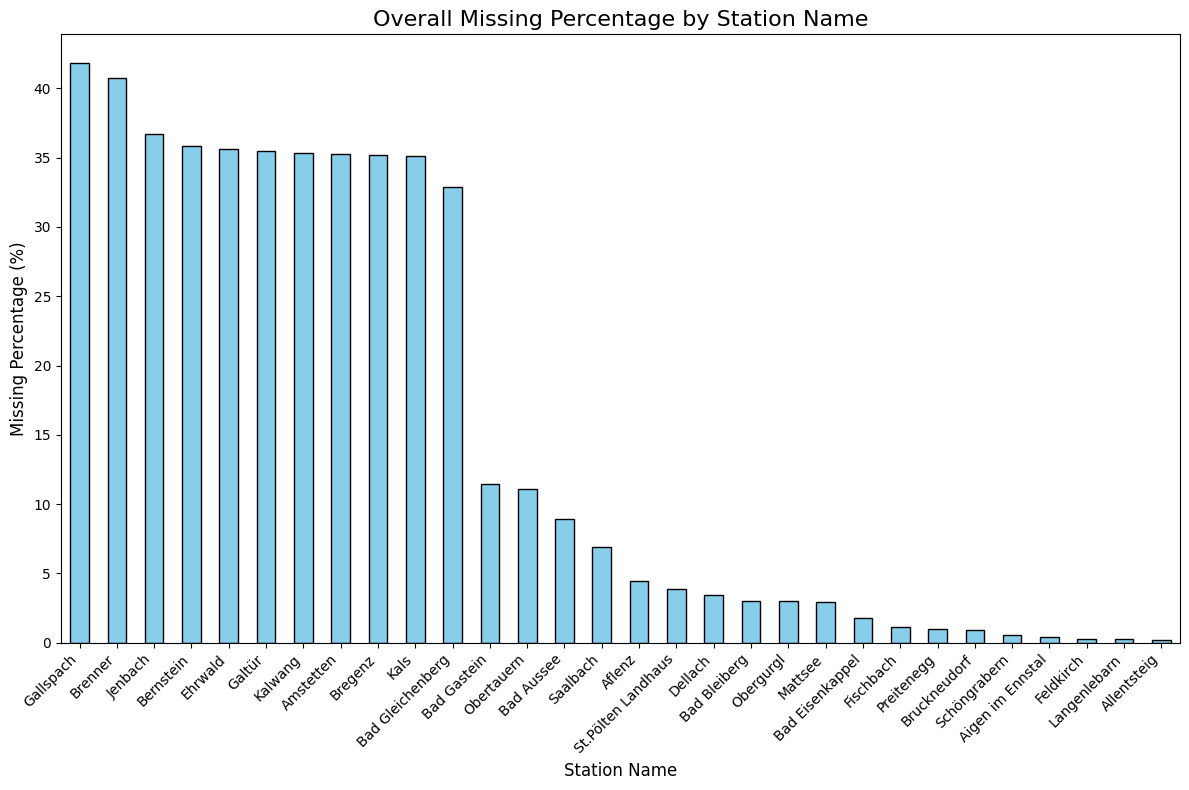

In [95]:
# Extract overall missing percentage
station_missing_summary = missing_by_name_sorted['Overall Missing Percentage']

plt.figure(figsize=(12, 8))
station_missing_summary.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Overall Missing Percentage by Station Name", fontsize=16)
plt.xlabel("Station Name", fontsize=12)
plt.ylabel("Missing Percentage (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We can see that some parameters are not measured for specific stations, leading to missing values.

# 5. Preprocessing

## 5.1 Check if there are missing values in target columns

In [96]:
rows_with_nan_tlmax = data_cleaned[data_cleaned['tlmax'].isnull()]
print('Rows with missing maximum temperature:', rows_with_nan_tlmax.shape[0])
print(rows_with_nan_tlmax['name'].value_counts())

Rows with missing maximum temperature: 328
name
Brenner         322
Bad Bleiberg      4
Obertauern        1
Saalbach          1
Name: count, dtype: int64


In [97]:
rows_with_nan_tlmin = data_cleaned[data_cleaned['tlmin'].isnull()]
print('Rows with missing minimum temperature:', rows_with_nan_tlmin.shape[0])
print(rows_with_nan_tlmin['name'].value_counts())

Rows with missing minimum temperature: 327
name
Brenner         322
Bad Bleiberg      4
Obertauern        1
Name: count, dtype: int64


In [44]:
rows_with_nan_tl_mittel = data_cleaned[data_cleaned['tl_mittel'].isnull()]
print('Rows with missing mean temperature:', rows_with_nan_tl_mittel.shape[0])
print(rows_with_nan_tl_mittel['name'].value_counts())

Rows with missing mean temperature: 328
name
Brenner         322
Bad Bleiberg      4
Obertauern        1
Saalbach          1
Name: count, dtype: int64


## 5.2 Drop columns with a high percentage of missing values

In [103]:
missing_percentage = data_cleaned.isnull().sum() / len(data_cleaned) * 100

# Identify columns with more than 10% missing values
columns_to_drop = missing_percentage[missing_percentage > 10].index
print('Columns to drop:', columns_to_drop)

Columns to drop: Index(['bewd_i', 'bewd_ii', 'bewd_iii', 'bewm_i', 'bewm_ii', 'bewm_iii',
       'bft6', 'bft8', 'cglo_j', 'erdb_i', 'erdb_ii', 'erdb_iii', 'gew',
       'glatt', 'nebel', 'raureif', 'reif', 'sh_manu', 'shneu_manu', 'sicht_i',
       'sicht_ii', 'sicht_iii', 'tau', 'tsmin', 'is_snowy'],
      dtype='object')


In [104]:
print("Current size of the dataset:", data_cleaned.shape)
data_cleaned = data_cleaned.drop(columns=columns_to_drop)
print("Size of dataset after removing columns with >10% of missing values:", data_cleaned.shape)

Current size of the dataset: (54810, 62)
Size of dataset after removing columns with >10% of missing values: (54810, 37)


## 5.3 Renaming columns

For better understanding let's rename the feature names:

In [ ]:
data_cleaned = data_cleaned.drop(['tl_i', 'tl_ii', 'tl_iii', 'date', 'zeitx', 'substation', 'name'], axis=1)


In [111]:
data_cleaned.columns.values

array(['id', 'dampf_i', 'dampf_ii', 'dampf_iii', 'dd32_i', 'dd32_ii',
       'dd32_iii', 'ffx', 'p_i', 'p_ii', 'p_iii', 'rf_i', 'rf_ii',
       'rf_iii', 'rr_i', 'rr_iii', 'so_h', 'tlmax', 'tlmin', 'tl_mittel',
       'vvbft_i', 'vvbft_ii', 'vvbft_iii', 'year', 'month', 'day', 'lat',
       'lon', 'regen_i', 'regen_ii'], dtype=object)

In [112]:
# New column names
new_columns = [
    'id',
    'vapor_pressure_1', 'vapor_pressure_2', 'vapor_pressure_3', 
    'wind_direction_1', 'wind_direction_2', 'wind_direction_3', 
    'max_wind_speed', 
    'air_pressure_1', 'air_pressure_2', 'air_pressure_3', 
    'relative_humidity_1', 'relative_humidity_2', 'relative_humidity_3', 
    'precipitation_1', 'precipitation_2', 
    'sunshine_duration', 
    'temperature_max', 'temperature_min', 'temperature_mean',
    'wind_strength_1', 'wind_strength_2', 'wind_strength_3', 
    'year', 'month', 'day', 
    'lat', 'lon', 
    'rain_indicator_1', 'rain_indicator_2'
]

data_cleaned.rename(columns=dict(zip(data_cleaned.columns, new_columns)), inplace=True)

In [113]:
print("Renamed dataset contains the following features:", data_cleaned.columns.values)

Renamed dataset contains the following features: ['id' 'vapor_pressure_1' 'vapor_pressure_2' 'vapor_pressure_3'
 'wind_direction_1' 'wind_direction_2' 'wind_direction_3' 'max_wind_speed'
 'air_pressure_1' 'air_pressure_2' 'air_pressure_3' 'relative_humidity_1'
 'relative_humidity_2' 'relative_humidity_3' 'precipitation_1'
 'precipitation_2' 'sunshine_duration' 'temperature_max' 'temperature_min'
 'temperature_mean' 'wind_strength_1' 'wind_strength_2' 'wind_strength_3'
 'year' 'month' 'day' 'lat' 'lon' 'rain_indicator_1' 'rain_indicator_2']


## 5.4 Lag features

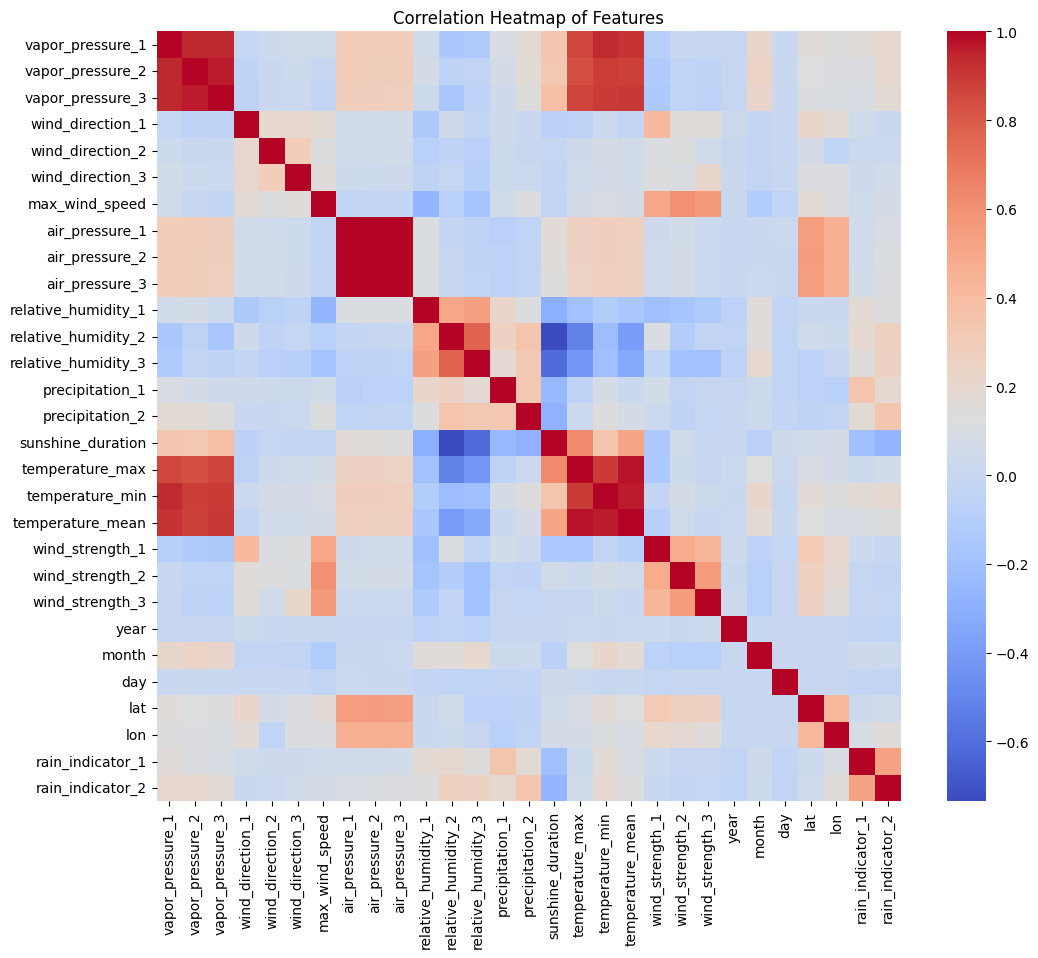

In [115]:
# Compute the correlation matrix
correlation_matrix = data_cleaned.drop(['id'], axis=1).corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', cbar=True)

# Add title
plt.title("Correlation Heatmap of Features")

# Show the plot
plt.show()

In [116]:
# Define target columns
target_columns = ['temperature_max', 'temperature_min', 'temperature_mean']

# Correlation of all features with the targets
correlation_with_target = correlation_matrix[target_columns]

# Display features with strong correlations (above 0.5 or below -0.5)
strong_correlation = correlation_with_target[(correlation_with_target.abs() > 0.5).any(axis=1)]
print("Features with strong correlation to targets:")
print(strong_correlation)

# Display features with weak correlations (below 0.1)
weak_correlation = correlation_with_target[(correlation_with_target.abs() < 0.1).all(axis=1)]
print("\nFeatures with weak correlation to targets:")
print(weak_correlation)

Features with strong correlation to targets:
                     temperature_max  temperature_min  temperature_mean
vapor_pressure_1            0.858815         0.935991          0.917338
vapor_pressure_2            0.835661         0.891251          0.883801
vapor_pressure_3            0.867009         0.893833          0.902996
relative_humidity_2        -0.514954        -0.224122         -0.397755
sunshine_duration           0.623802         0.347747          0.516171
temperature_max             1.000000         0.891771          0.978832
temperature_min             0.891771         1.000000          0.965489
temperature_mean            0.978832         0.965489          1.000000

Features with weak correlation to targets:
                  temperature_max  temperature_min  temperature_mean
wind_direction_1        -0.054054         0.021109         -0.021537
wind_direction_2         0.038592         0.077026          0.057103
wind_direction_3         0.050133         0.076320      

We will drop some features with weak correlation to targets:

In [117]:
data_cleaned = data_cleaned.drop(['wind_direction_1', 'wind_direction_2', 'wind_direction_3', 'wind_strength_1', 'wind_strength_2', 'wind_strength_3', 'precipitation_1', 'precipitation_2'], axis=1)

In [118]:
features_to_lag = [
    'vapor_pressure_1', 
    'vapor_pressure_2',
    'vapor_pressure_3', 
    'sunshine_duration', 
    'temperature_max',
    'temperature_mean',
    'temperature_min'
]

In [119]:
# Define lag periods
lags = [7, 14, 28]

# Create lagged features for grouped data
for lag in lags:
    for feature in features_to_lag:
        # Group by station and apply shift
        data_cleaned[f'{feature}_lag_{lag}'] = data_cleaned.groupby('id')[feature].shift(lag)

For the first 28 days of 2016 we will not be able to extract lag features, so we will drop the rows with these days:

In [122]:
data_cleaned = data_cleaned[~((data_cleaned['year'] == 2016) & (data_cleaned['month'] == 1) & (data_cleaned['day'] <= 28))]

In [123]:
print(data_cleaned[['id', 'year', 'month', 'day', 'temperature_mean', 'temperature_mean_lag_7']].head(20))

     id  year  month  day  temperature_mean  temperature_mean_lag_7
840   8  2016      1   29               6.4                    -2.5
841  66  2016      1   29               1.5                    -6.0
842  68  2016      1   29               1.8                    -9.1
843  93  2016      1   29               7.8                    -7.6
844  27  2016      1   29               6.4                    -8.8
845   7  2016      1   29               2.4                    -9.2
846  18  2016      1   29               7.0                    -5.4
847  24  2016      1   29               7.8                    -5.1
848  42  2016      1   29               5.1                    -5.8
849  44  2016      1   29               5.3                   -10.4
850   4  2016      1   29               6.2                    -9.5
851  13  2016      1   29               6.7                    -5.5
852  21  2016      1   29               4.2                    -5.8
853  28  2016      1   29               1.7     

In [124]:
# Check if everything's correct
filtered_row = data_cleaned[
    (data_cleaned['id'] == 8) & 
    (data_cleaned['year'] == 2016) & 
    (data_cleaned['month'] == 4) & 
    (data_cleaned['day'] == 1)
]

print(filtered_row['temperature_mean_lag_7'], filtered_row['temperature_mean_lag_14'], filtered_row['temperature_mean_lag_28'])

check_row_7 = data_cleaned[
    (data_cleaned['id'] == 8) & 
    (data_cleaned['year'] == 2016) & 
    (data_cleaned['month'] == 3) & 
    (data_cleaned['day'] == 25)
]

check_row_14 = data_cleaned[
    (data_cleaned['id'] == 8) & 
    (data_cleaned['year'] == 2016) & 
    (data_cleaned['month'] == 3) & 
    (data_cleaned['day'] == 18)
]

check_row_28 = data_cleaned[
    (data_cleaned['id'] == 8) & 
    (data_cleaned['year'] == 2016) & 
    (data_cleaned['month'] == 3) & 
    (data_cleaned['day'] == 4)
]

print(check_row_7['temperature_mean'], check_row_14['temperature_mean'], check_row_28['temperature_mean'])

2730    6.4
Name: temperature_mean_lag_7, dtype: float64 2730    6.3
Name: temperature_mean_lag_14, dtype: float64 2730    6.3
Name: temperature_mean_lag_28, dtype: float64
2520    6.4
Name: temperature_mean, dtype: float64 2310    6.3
Name: temperature_mean, dtype: float64 1890    6.3
Name: temperature_mean, dtype: float64


## 5.5. Impute missing values for features with <10% missing values

Now we will input the missing values for the columns with <10% of missing values. To avoid data leakage, the imputation should be done separately for training, validation and testing data after splitting the dataset by year.

In [129]:
# Split the data into training (2016-2018), validation (2019) and testing (2020)
train_data = data_cleaned[data_cleaned['year'] < 2019]  # Train: 2016-2018
val_data = data_cleaned[data_cleaned['year'] == 2019]   # Validation: 2019
test_data = data_cleaned[data_cleaned['year'] == 2020]  # Test: 2020

In [130]:
# Initialize the KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNNImputer separately
train_data_imputed = pd.DataFrame(knn_imputer.fit_transform(train_data), columns=train_data.columns)
val_data_imputed = pd.DataFrame(knn_imputer.fit_transform(val_data), columns=val_data.columns)
test_data_imputed = pd.DataFrame(knn_imputer.fit_transform(test_data), columns=test_data.columns)

In [137]:
train_data_imputed

,id,vapor_pressure_1,vapor_pressure_2,vapor_pressure_3,max_wind_speed,air_pressure_1,air_pressure_2,air_pressure_3,relative_humidity_1,relative_humidity_2,...,temperature_mean_target_32,temperature_max_target_33,temperature_min_target_33,temperature_mean_target_33,temperature_max_target_34,temperature_min_target_34,temperature_mean_target_34,temperature_max_target_35,temperature_min_target_35,temperature_mean_target_35
0,8.0,6.6,8.1,6.7,7.0,995.5,995.90,997.70,92.0,61.0,...,6.8,12.0,-1.2,5.4,8.4,2.5,5.5,11.1,1.5,6.3
1,66.0,4.4,4.4,3.1,4.7,812.7,813.70,814.70,73.0,53.0,...,-5.0,4.3,-7.7,-1.7,0.2,-8.8,-4.3,0.6,-11.4,-5.4
2,68.0,6.1,5.2,4.7,12.2,832.0,833.40,834.20,94.0,70.0,...,-4.2,3.3,-6.2,-1.5,-0.2,-8.1,-4.2,-0.9,-8.3,-4.6
3,93.0,8.6,8.2,7.9,14.7,995.7,997.00,996.80,95.0,74.0,...,3.8,10.7,1.5,6.1,7.0,2.2,4.6,7.8,1.0,4.4
4,27.0,9.0,9.2,8.6,6.9,947.2,945.84,946.04,100.0,97.0,...,2.1,7.3,-0.5,3.4,6.2,0.7,3.5,7.0,0.5,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30985,37.0,7.8,7.6,7.2,11.2,973.7,974.30,976.40,91.0,89.0,...,5.7,5.7,2.0,3.9,5.7,1.0,3.4,6.0,0.6,3.3
30986,20.0,5.2,5.7,6.1,4.2,891.6,892.20,894.40,91.0,83.0,...,-1.2,-0.1,-7.5,-3.8,1.9,-4.4,-1.3,1.2,-0.5,0.4
30987,71.0,6.2,6.5,6.2,6.4,882.3,883.10,884.90,100.0,100.0,...,3.6,6.5,-0.5,3.0,5.0,-2.5,1.3,5.3,-0.4,2.5
30988,43.0,5.0,4.5,5.8,10.9,848.6,848.70,850.90,87.0,58.0,...,5.0,6.7,0.5,3.6,3.2,-2.4,0.4,2.3,-2.0,0.2


## 5.6 Defining the forecast horizon

In [138]:
# Define the forecast horizons in days
forecast_horizons = range(21, 36)  # Predict for 21 to 35 days ahead

# Create target columns
for horizon in forecast_horizons:
    for target in ['temperature_max', 'temperature_min', 'temperature_mean']:
        train_data_imputed[f'{target}_target_{horizon}'] = train_data_imputed.groupby('id')[target].shift(-horizon)
        val_data_imputed[f'{target}_target_{horizon}'] = val_data_imputed.groupby('id')[target].shift(-horizon)
        test_data_imputed[f'{target}_target_{horizon}'] = test_data_imputed.groupby('id')[target].shift(-horizon)

After defining the forecast horizon, some rows at the end of each station's data will have NaN in the target columns due to shifting. Drop these rows:

In [139]:
# Drop rows with NaN values in the target columns
target_cols = [f'{target}_target_{horizon}' for horizon in forecast_horizons for target in ['temperature_max', 'temperature_min', 'temperature_mean']]
train_data_imputed = train_data_imputed.dropna(subset=target_cols).reset_index(drop=True)
val_data_imputed = val_data_imputed.dropna(subset=target_cols).reset_index(drop=True)
test_data_imputed = test_data_imputed.dropna(subset=target_cols).reset_index(drop=True)

In [140]:
print(train_data_imputed[['id', 'year', 'month', 'day', 'temperature_mean_target_21']].head(20))

      id    year  month   day  temperature_mean_target_21
0    8.0  2016.0    1.0  29.0                         5.2
1   66.0  2016.0    1.0  29.0                        -6.4
2   68.0  2016.0    1.0  29.0                        -3.5
3   93.0  2016.0    1.0  29.0                         4.6
4   27.0  2016.0    1.0  29.0                         4.2
5    7.0  2016.0    1.0  29.0                         0.2
6   18.0  2016.0    1.0  29.0                         4.5
7   24.0  2016.0    1.0  29.0                         3.2
8   42.0  2016.0    1.0  29.0                         3.5
9   44.0  2016.0    1.0  29.0                         3.0
10   4.0  2016.0    1.0  29.0                         4.8
11  13.0  2016.0    1.0  29.0                         2.5
12  21.0  2016.0    1.0  29.0                         2.3
13  28.0  2016.0    1.0  29.0                        -4.4
14  16.0  2016.0    1.0  29.0                        -0.7
15  25.0  2016.0    1.0  29.0                         0.5
16  83.0  2016

## 5.7 Defining input and target features

In [141]:
input_features = [col for col in train_data_imputed.columns if 'target' not in col and 'id' not in col]
input_features

['vapor_pressure_1',
 'vapor_pressure_2',
 'vapor_pressure_3',
 'max_wind_speed',
 'air_pressure_1',
 'air_pressure_2',
 'air_pressure_3',
 'sunshine_duration',
 'temperature_max',
 'temperature_min',
 'temperature_mean',
 'year',
 'month',
 'day',
 'lat',
 'lon',
 'rain_indicator_1',
 'rain_indicator_2',
 'vapor_pressure_1_lag_7',
 'vapor_pressure_2_lag_7',
 'vapor_pressure_3_lag_7',
 'sunshine_duration_lag_7',
 'temperature_max_lag_7',
 'temperature_mean_lag_7',
 'temperature_min_lag_7',
 'vapor_pressure_1_lag_14',
 'vapor_pressure_2_lag_14',
 'vapor_pressure_3_lag_14',
 'sunshine_duration_lag_14',
 'temperature_max_lag_14',
 'temperature_mean_lag_14',
 'temperature_min_lag_14',
 'vapor_pressure_1_lag_28',
 'vapor_pressure_2_lag_28',
 'vapor_pressure_3_lag_28',
 'sunshine_duration_lag_28',
 'temperature_max_lag_28',
 'temperature_mean_lag_28',
 'temperature_min_lag_28']

In [142]:
# Define target columns for all forecast horizons
target_features = [f'temperature_max_target_{horizon}' for horizon in forecast_horizons] + \
                  [f'temperature_min_target_{horizon}' for horizon in forecast_horizons] + \
                  [f'temperature_mean_target_{horizon}' for horizon in forecast_horizons]

target_features

['temperature_max_target_21',
 'temperature_max_target_22',
 'temperature_max_target_23',
 'temperature_max_target_24',
 'temperature_max_target_25',
 'temperature_max_target_26',
 'temperature_max_target_27',
 'temperature_max_target_28',
 'temperature_max_target_29',
 'temperature_max_target_30',
 'temperature_max_target_31',
 'temperature_max_target_32',
 'temperature_max_target_33',
 'temperature_max_target_34',
 'temperature_max_target_35',
 'temperature_min_target_21',
 'temperature_min_target_22',
 'temperature_min_target_23',
 'temperature_min_target_24',
 'temperature_min_target_25',
 'temperature_min_target_26',
 'temperature_min_target_27',
 'temperature_min_target_28',
 'temperature_min_target_29',
 'temperature_min_target_30',
 'temperature_min_target_31',
 'temperature_min_target_32',
 'temperature_min_target_33',
 'temperature_min_target_34',
 'temperature_min_target_35',
 'temperature_mean_target_21',
 'temperature_mean_target_22',
 'temperature_mean_target_23',
 'tempe

Split to test the model on one step (21):

In [144]:
# Split the data into inputs (X) and targets (y)
X_train = train_data_imputed[input_features]
y_train = train_data_imputed['temperature_max_target_21']

X_val = val_data_imputed[input_features]  # ✅ Validation Set
y_val = val_data_imputed['temperature_max_target_21']

X_test = test_data_imputed[input_features]
y_test = test_data_imputed['temperature_max_target_21']

In [145]:
y_train

0         6.2
1        -3.2
2        -1.1
3         7.4
4         6.0
         ... 
29935     9.0
29936    18.7
29937    13.6
29938    13.0
29939    18.0
Name: temperature_max_target_21, Length: 29940, dtype: float64

On multi-target features set:

In [146]:
X_train_full = train_data_imputed[input_features]
y_train_full = train_data_imputed[target_features]

X_val_full = val_data_imputed[input_features] 
y_val_full = val_data_imputed[target_features]

X_test_full = test_data_imputed[input_features]
y_test_full = test_data_imputed[target_features]

## 5.8 Scaling

In [147]:
# Initialize the scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) 

In [150]:
# Initialize the scaler
full_scaler = StandardScaler()

X_train_full_scaled = full_scaler.fit_transform(X_train_full)
X_val_full_scaled = full_scaler.transform(X_val_full)
X_test_full_scaled = full_scaler.transform(X_test_full)

## 6. Saving the resulted sets

In [155]:
# Convert NumPy arrays to DataFrames and save as CSV
pd.DataFrame(X_train_scaled).to_csv('../results/X_train_scaled.csv', index=False)
pd.DataFrame(y_train).to_csv('../results/y_train.csv', index=False)

pd.DataFrame(X_val_scaled).to_csv('../results/X_val_scaled.csv', index=False)
pd.DataFrame(y_val).to_csv('../results/y_val.csv', index=False)

pd.DataFrame(X_test_scaled).to_csv('../results/X_test_scaled.csv', index=False)
pd.DataFrame(y_test).to_csv('../results/y_test.csv', index=False)

pd.DataFrame(X_train_full_scaled).to_csv('../results/X_train_full_scaled.csv', index=False)
pd.DataFrame(y_train_full).to_csv('../results/y_train_full.csv', index=False)

pd.DataFrame(X_val_full_scaled).to_csv('../results/X_val_full_scaled.csv', index=False)
pd.DataFrame(y_val_full).to_csv('../results/y_val_full.csv', index=False)

pd.DataFrame(X_test_full_scaled).to_csv('../results/X_test_full_scaled.csv', index=False)
pd.DataFrame(y_test_full).to_csv('../results/y_test_full.csv', index=False)

pd.DataFrame({'input_features': input_features}).to_csv('../results/input_features.csv', index=False)
pd.DataFrame({'target_features': target_features}).to_csv('../results/target_features.csv', index=False)

print("✅ Data saved successfully as CSV files!")

✅ Data saved successfully as CSV files!
